In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from skimage.transform import resize
from scipy.ndimage import gaussian_filter

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity,
    mean_squared_error
)

print("KLA Generalization + NAF-SR Experiment")
print("PyTorch:", torch.__version__)

KLA Generalization + NAF-SR Experiment
PyTorch: 2.5.1+cu121


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Quadro GV100


In [3]:
GT_PATH = "../data/train/GT"
NOISY_PATH = "../data/train/NoisyLR"

files = sorted([
    f for f in os.listdir(GT_PATH)
    if f.endswith(".npy")
])

print("Total pairs:", len(files))

print(
    "GT exists:",
    os.path.exists(GT_PATH)
)

print(
    "NoisyLR exists:",
    os.path.exists(NOISY_PATH)
)

Total pairs: 3200
GT exists: True
NoisyLR exists: True


In [4]:
np.random.seed(SEED)

indices = np.random.permutation(
    len(files)
)

train_end = int(
    0.80 * len(files)
)

val_end = int(
    0.90 * len(files)
)

train_files = [
    files[i]
    for i in indices[:train_end]
]

val_files = [
    files[i]
    for i in indices[
        train_end:val_end
    ]
]

test_files = [
    files[i]
    for i in indices[
        val_end:
    ]
]

print("Train:", len(train_files))
print("Validation:", len(val_files))
print("Test:", len(test_files))

Train: 2560
Validation: 320
Test: 320


In [5]:
def synthetic_degrade(
    gt,
    scale=2
):

    gt = gt.astype(
        np.float32
    )

    h, w = gt.shape

    # -------------------
    # 1. Random blur
    # -------------------

    if np.random.rand() < 0.7:

        sigma = np.random.uniform(
            0.0,
            1.2
        )

        blurred = gaussian_filter(
            gt,
            sigma=sigma
        )

    else:

        blurred = gt


    # -------------------
    # 2. Downsampling
    # -------------------

    lr = resize(
        blurred,
        (
            h // scale,
            w // scale
        ),
        order=np.random.choice(
            [1, 3]
        ),
        anti_aliasing=True,
        preserve_range=True
    ).astype(
        np.float32
    )


    # -------------------
    # 3. Speckle noise
    # -------------------

    if np.random.rand() < 0.8:

        speckle_sigma = np.random.uniform(
            0.01,
            0.18
        )

        speckle = np.random.normal(
            0,
            speckle_sigma,
            lr.shape
        ).astype(
            np.float32
        )

        lr = lr * (
            1.0 + speckle
        )


    # -------------------
    # 4. Gaussian noise
    # -------------------

    if np.random.rand() < 0.8:

        gaussian_sigma = np.random.uniform(
            0.0,
            0.06
        )

        gaussian = np.random.normal(
            0,
            gaussian_sigma,
            lr.shape
        ).astype(
            np.float32
        )

        lr = lr + gaussian


    # -------------------
    # 5. Intensity change
    # -------------------

    if np.random.rand() < 0.4:

        gain = np.random.uniform(
            0.9,
            1.1
        )

        bias = np.random.uniform(
            -0.03,
            0.03
        )

        lr = (
            lr * gain
            +
            bias
        )


    # IMPORTANT:
    # no [0,1] clipping here

    return lr.astype(
        np.float32
    )

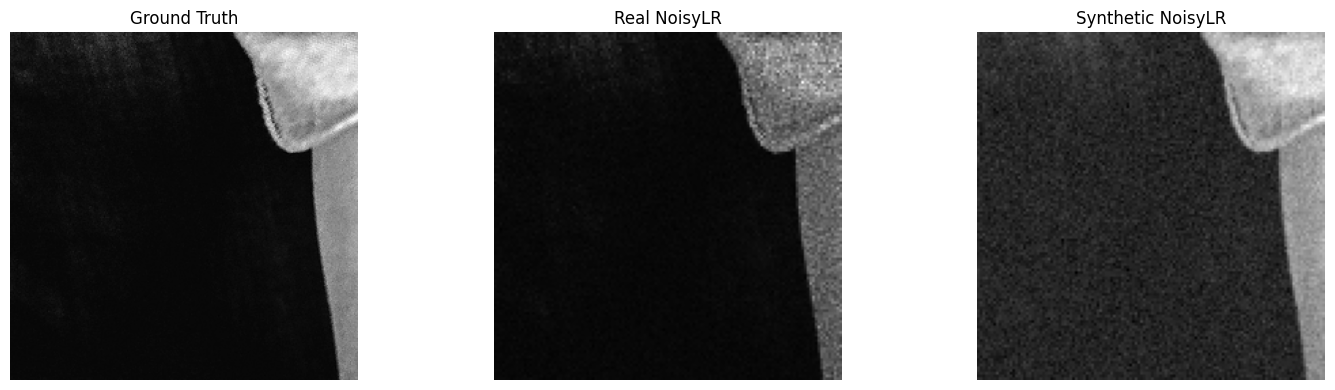

Real range: -0.013836689 1.4661262
Synthetic range: -0.1400747 0.9513364


In [6]:
sample_file = train_files[0]

gt = np.load(
    os.path.join(
        GT_PATH,
        sample_file
    )
).astype(
    np.float32
)

real_lr = np.load(
    os.path.join(
        NOISY_PATH,
        sample_file
    )
).astype(
    np.float32
)

synthetic_lr = synthetic_degrade(
    gt
)

plt.figure(
    figsize=(15,4)
)

plt.subplot(1,3,1)
plt.imshow(gt, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(real_lr, cmap="gray")
plt.title("Real NoisyLR")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(synthetic_lr, cmap="gray")
plt.title("Synthetic NoisyLR")
plt.axis("off")

plt.tight_layout()
plt.show()

print(
    "Real range:",
    real_lr.min(),
    real_lr.max()
)

print(
    "Synthetic range:",
    synthetic_lr.min(),
    synthetic_lr.max()
)

In [9]:
class KLATrainDataset(Dataset):

    def __init__(
        self,
        gt_path,
        noisy_path,
        files,
        synthetic_probability=0.30
    ):

        self.gt_path = gt_path
        self.noisy_path = noisy_path
        self.files = files

        self.synthetic_probability = (
            synthetic_probability
        )


    def __len__(self):

        return len(self.files)


    def __getitem__(
        self,
        idx
    ):

        filename = self.files[idx]

        gt = np.load(
            os.path.join(
                self.gt_path,
                filename
            )
        ).astype(
            np.float32
        )


        if (
            np.random.rand()
            <
            self.synthetic_probability
        ):

            lr = synthetic_degrade(
                gt
            )

        else:

            lr = np.load(
                os.path.join(
                    self.noisy_path,
                    filename
                )
            ).astype(
                np.float32
            )


        lr = torch.from_numpy(
            lr
        ).unsqueeze(0)

        gt = torch.from_numpy(
            gt
        ).unsqueeze(0)


        return lr, gt

In [10]:
class KLARealDataset(Dataset):

    def __init__(
        self,
        gt_path,
        noisy_path,
        files
    ):

        self.gt_path = gt_path
        self.noisy_path = noisy_path
        self.files = files


    def __len__(self):

        return len(self.files)


    def __getitem__(
        self,
        idx
    ):

        filename = self.files[idx]


        gt = np.load(
            os.path.join(
                self.gt_path,
                filename
            )
        ).astype(
            np.float32
        )


        lr = np.load(
            os.path.join(
                self.noisy_path,
                filename
            )
        ).astype(
            np.float32
        )


        lr = torch.from_numpy(
            lr
        ).unsqueeze(0)

        gt = torch.from_numpy(
            gt
        ).unsqueeze(0)


        return lr, gt

In [11]:
train_dataset = KLATrainDataset(
    GT_PATH,
    NOISY_PATH,
    train_files,
    synthetic_probability=0.30
)

val_dataset = KLARealDataset(
    GT_PATH,
    NOISY_PATH,
    val_files
)

test_dataset = KLARealDataset(
    GT_PATH,
    NOISY_PATH,
    test_files
)


BATCH_SIZE = 8


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2560
Validation: 320
Test: 320


In [17]:
class SimpleGate(nn.Module):

    def forward(
        self,
        x
    ):

        x1, x2 = x.chunk(
            2,
            dim=1
        )

        return x1 * x2

In [18]:
class NAFBlock(nn.Module):

    def __init__(
        self,
        channels,
        expansion=2
    ):

        super().__init__()


        hidden = (
            channels
            *
            expansion
        )


        self.norm1 = nn.GroupNorm(
            1,
            channels
        )


        self.conv1 = nn.Conv2d(
            channels,
            hidden * 2,
            kernel_size=1
        )


        self.dwconv = nn.Conv2d(
            hidden * 2,
            hidden * 2,
            kernel_size=3,
            padding=1,
            groups=hidden * 2
        )


        self.gate = SimpleGate()


        self.channel_attention = nn.Sequential(

            nn.AdaptiveAvgPool2d(1),

            nn.Conv2d(
                hidden,
                hidden,
                kernel_size=1
            )
        )


        self.conv2 = nn.Conv2d(
            hidden,
            channels,
            kernel_size=1
        )


        self.norm2 = nn.GroupNorm(
            1,
            channels
        )


        self.ffn1 = nn.Conv2d(
            channels,
            channels * 2,
            kernel_size=1
        )


        self.ffn_gate = SimpleGate()


        self.ffn2 = nn.Conv2d(
            channels,
            channels,
            kernel_size=1
        )


        self.beta = nn.Parameter(
            torch.zeros(
                1,
                channels,
                1,
                1
            )
        )


        self.gamma = nn.Parameter(
            torch.zeros(
                1,
                channels,
                1,
                1
            )
        )


    def forward(
        self,
        x
    ):

        y = self.norm1(
            x
        )

        y = self.conv1(
            y
        )

        y = self.dwconv(
            y
        )

        y = self.gate(
            y
        )

        attention = (
            self.channel_attention(
                y
            )
        )

        y = y * attention

        y = self.conv2(
            y
        )


        x = (
            x
            +
            self.beta * y
        )


        y = self.norm2(
            x
        )

        y = self.ffn1(
            y
        )

        y = self.ffn_gate(
            y
        )

        y = self.ffn2(
            y
        )


        return (
            x
            +
            self.gamma * y
        )

In [20]:
class NAFSR(nn.Module):

    def __init__(
        self,
        channels=48,
        num_blocks=8,
        scale=2
    ):

        super().__init__()


        self.scale = scale


        self.head = nn.Conv2d(
            1,
            channels,
            kernel_size=3,
            padding=1
        )


        self.body = nn.Sequential(
            *[
                NAFBlock(
                    channels
                )
                for _ in range(
                    num_blocks
                )
            ]
        )


        self.body_conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=3,
            padding=1
        )


        self.up = nn.Sequential(

            nn.Conv2d(
                channels,
                channels
                *
                scale
                *
                scale,
                kernel_size=3,
                padding=1
            ),

            nn.PixelShuffle(
                scale
            ),

            nn.Conv2d(
                channels,
                1,
                kernel_size=3,
                padding=1
            )
        )


    def forward(
        self,
        x
    ):

        features = self.head(
            x
        )

        residual = features


        features = self.body(
            features
        )


        features = self.body_conv(
            features
        )


        features = (
            features
            +
            residual
        )


        output = self.up(
            features
        )


        return output

In [21]:
model = NAFSR(
    channels=48,
    num_blocks=8,
    scale=2
).to(
    device
)

print(model)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    "Parameters:",
    total_params
)

NAFSR(
  (head): Conv2d(1, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (body): Sequential(
    (0): NAFBlock(
      (norm1): GroupNorm(1, 48, eps=1e-05, affine=True)
      (conv1): Conv2d(48, 192, kernel_size=(1, 1), stride=(1, 1))
      (dwconv): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=192)
      (gate): SimpleGate()
      (channel_attention): Sequential(
        (0): AdaptiveAvgPool2d(output_size=1)
        (1): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1))
      )
      (conv2): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1))
      (norm2): GroupNorm(1, 48, eps=1e-05, affine=True)
      (ffn1): Conv2d(48, 96, kernel_size=(1, 1), stride=(1, 1))
      (ffn_gate): SimpleGate()
      (ffn2): Conv2d(48, 48, kernel_size=(1, 1), stride=(1, 1))
    )
    (1): NAFBlock(
      (norm1): GroupNorm(1, 48, eps=1e-05, affine=True)
      (conv1): Conv2d(48, 192, kernel_size=(1, 1), stride=(1, 1))
      (dwconv): Conv2d(192, 192, kernel_size=(3, 

In [22]:
dummy = torch.randn(
    1,
    1,
    128,
    128
).to(
    device
)

with torch.no_grad():

    output = model(
        dummy
    )

print(
    "Input:",
    dummy.shape
)

print(
    "Output:",
    output.shape
)

Input: torch.Size([1, 1, 128, 128])
Output: torch.Size([1, 1, 256, 256])


In [23]:
def gaussian_window(
    window_size=11,
    sigma=1.5,
    channels=1,
    device="cpu"
):

    coords = torch.arange(
        window_size,
        dtype=torch.float32,
        device=device
    )

    coords = (
        coords
        -
        window_size // 2
    )

    g = torch.exp(
        -(
            coords ** 2
        )
        /
        (
            2 * sigma ** 2
        )
    )

    g = g / g.sum()

    window = (
        g[:, None]
        *
        g[None, :]
    )

    window = window.expand(
        channels,
        1,
        window_size,
        window_size
    )

    return window

In [24]:
def differentiable_ssim(
    x,
    y,
    window_size=11
):

    channels = x.shape[1]

    window = gaussian_window(
        window_size,
        1.5,
        channels,
        x.device
    )


    mu_x = F.conv2d(
        x,
        window,
        padding=window_size//2,
        groups=channels
    )


    mu_y = F.conv2d(
        y,
        window,
        padding=window_size//2,
        groups=channels
    )


    mu_x_sq = mu_x ** 2
    mu_y_sq = mu_y ** 2
    mu_xy = mu_x * mu_y


    sigma_x = (
        F.conv2d(
            x*x,
            window,
            padding=window_size//2,
            groups=channels
        )
        -
        mu_x_sq
    )


    sigma_y = (
        F.conv2d(
            y*y,
            window,
            padding=window_size//2,
            groups=channels
        )
        -
        mu_y_sq
    )


    sigma_xy = (
        F.conv2d(
            x*y,
            window,
            padding=window_size//2,
            groups=channels
        )
        -
        mu_xy
    )


    C1 = 0.01 ** 2
    C2 = 0.03 ** 2


    ssim_map = (
        (
            2 * mu_xy
            +
            C1
        )
        *
        (
            2 * sigma_xy
            +
            C2
        )
    ) / (
        (
            mu_x_sq
            +
            mu_y_sq
            +
            C1
        )
        *
        (
            sigma_x
            +
            sigma_y
            +
            C2
        )
        +
        1e-8
    )


    return ssim_map.mean()

In [25]:
def restoration_loss(
    output,
    target
):

    l1 = F.l1_loss(
        output,
        target
    )

    ssim_value = differentiable_ssim(
        output,
        target
    )

    ssim_loss = (
        1.0
        -
        ssim_value
    )


    total = (
        l1
        +
        0.10
        *
        ssim_loss
    )


    return (
        total,
        l1,
        ssim_loss
    )

In [26]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30,
    eta_min=1e-6
)

print(
    "Optimizer ready"
)

Optimizer ready


In [27]:
MODEL_DIR = "../models/nafsr"

RESULT_DIR = "../results/nafsr"

RESTORED_DIR = "../results/nafsr/restored"

IMAGE_DIR = "../results/nafsr/images"

for path in [
    MODEL_DIR,
    RESULT_DIR,
    RESTORED_DIR,
    IMAGE_DIR
]:

    os.makedirs(
        path,
        exist_ok=True
    )

print(
    "Output folders ready"
)

Output folders ready


In [28]:
EPOCHS = 30

train_history = []
val_history = []

best_val = float(
    "inf"
)


for epoch in range(
    EPOCHS
):

    # =========================
    # TRAIN
    # =========================

    model.train()

    train_loss_sum = 0.0


    for lr, gt in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    ):

        lr = lr.to(
            device,
            non_blocking=True
        )

        gt = gt.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        output = model(
            lr
        )


        (
            loss,
            l1_loss,
            ssim_loss
        ) = restoration_loss(
            output,
            gt
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )


        optimizer.step()


        train_loss_sum += (
            loss.item()
        )


    train_loss = (
        train_loss_sum
        /
        len(train_loader)
    )


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    val_loss_sum = 0.0


    with torch.no_grad():

        for lr, gt in val_loader:

            lr = lr.to(
                device,
                non_blocking=True
            )

            gt = gt.to(
                device,
                non_blocking=True
            )


            output = model(
                lr
            )


            (
                loss,
                _,
                _
            ) = restoration_loss(
                output,
                gt
            )


            val_loss_sum += (
                loss.item()
            )


    val_loss = (
        val_loss_sum
        /
        len(val_loader)
    )


    train_history.append(
        train_loss
    )

    val_history.append(
        val_loss
    )


    scheduler.step()


    print(
        f"Epoch [{epoch+1:02d}/{EPOCHS}] "
        f"Train: {train_loss:.6f} | "
        f"Val: {val_loss:.6f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.7f}"
    )


    if val_loss < best_val:

        best_val = val_loss

        checkpoint = {

            "epoch":
                epoch + 1,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "val_loss":
                val_loss,

            "config": {
                "channels": 48,
                "blocks": 8,
                "scale": 2,
                "synthetic_probability": 0.30
            }
        }


        torch.save(
            checkpoint,
            "../models/nafsr/nafsr_best.pth"
        )


        print(
            "Best model saved"
        )

Epoch 1/30: 100%|██████████| 320/320 [02:10<00:00,  2.46it/s]


Epoch [01/30] Train: 0.092715 | Val: 0.081948 | LR: 0.0001995
Best model saved


Epoch 2/30: 100%|██████████| 320/320 [02:07<00:00,  2.51it/s]


Epoch [02/30] Train: 0.076084 | Val: 0.074434 | LR: 0.0001978
Best model saved


Epoch 3/30: 100%|██████████| 320/320 [02:08<00:00,  2.49it/s]


...

Epoch [28/30] Train: 0.060373 | Val: 0.060897 | LR: 0.0000032


Epoch 29/30: 100%|██████████| 320/320 [02:09<00:00,  2.46it/s]


Epoch [29/30] Train: 0.060405 | Val: 0.060838 | LR: 0.0000015
Best model saved


Epoch 30/30: 100%|██████████| 320/320 [02:09<00:00,  2.46it/s]


Epoch [30/30] Train: 0.060249 | Val: 0.060816 | LR: 0.0000010
Best model saved


In [29]:
checkpoint = torch.load(
    "../models/nafsr/nafsr_best.pth",
    map_location=device
)

best_model = NAFSR(
    channels=checkpoint["config"]["channels"],
    num_blocks=checkpoint["config"]["blocks"],
    scale=checkpoint["config"]["scale"]
).to(device)

best_model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_model.eval()

print("Loaded epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])
print("Config:", checkpoint["config"])

/tmp/ipykernel_3561318/1387106288.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Loaded epoch: 30
Best validation loss: 0.06081562796607613
Config: {'channels': 48, 'blocks': 8, 'scale': 2, 'synthetic_probability': 0.3}


In [30]:
history_df = pd.DataFrame({
    "Epoch": range(1, len(train_history) + 1),
    "Train_Loss": train_history,
    "Val_Loss": val_history
})

history_df.to_csv(
    "../results/nafsr/training_history.csv",
    index=False
)

history_df.tail()

,Epoch,Train_Loss,Val_Loss
25,26,0.060330,0.060969
26,27,0.060194,0.060895
27,28,0.060373,0.060897
28,29,0.060405,0.060838
29,30,0.060249,0.060816


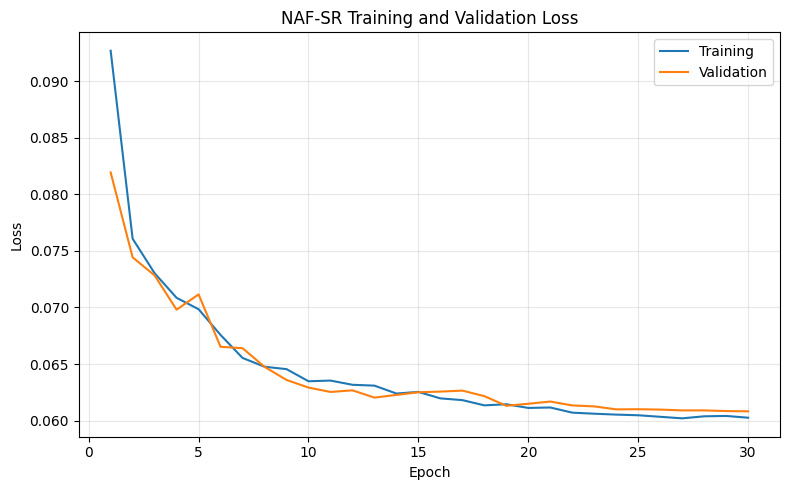

In [31]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(train_history)+1),
    train_history,
    label="Training"
)

plt.plot(
    range(1, len(val_history)+1),
    val_history,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NAF-SR Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../results/nafsr/training_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [32]:
psnr_scores = []
ssim_scores = []
mse_scores = []
inference_times = []

best_model.eval()

with torch.no_grad():

    for i, (lr, gt) in enumerate(
        tqdm(test_loader, desc="Testing NAF-SR")
    ):

        lr = lr.to(
            device,
            non_blocking=True
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()

        output = best_model(lr)

        if device.type == "cuda":
            torch.cuda.synchronize()

        elapsed_ms = (
            time.perf_counter() - start
        ) * 1000

        # Clamp only restored prediction
        output = torch.clamp(
            output,
            0,
            1
        )

        restored = (
            output.squeeze()
            .cpu()
            .numpy()
        )

        gt_np = (
            gt.squeeze()
            .numpy()
        )

        psnr_value = peak_signal_noise_ratio(
            gt_np,
            restored,
            data_range=1.0
        )

        ssim_value = structural_similarity(
            gt_np,
            restored,
            data_range=1.0
        )

        mse_value = mean_squared_error(
            gt_np,
            restored
        )

        psnr_scores.append(psnr_value)
        ssim_scores.append(ssim_value)
        mse_scores.append(mse_value)
        inference_times.append(elapsed_ms)

        filename = test_files[i]

        np.save(
            os.path.join(
                RESTORED_DIR,
                filename
            ),
            restored.astype(np.float32)
        )

print("Testing complete")

Testing NAF-SR: 100%|██████████| 320/320 [00:13<00:00, 24.10it/s]

Testing complete


In [33]:
avg_psnr = np.mean(psnr_scores)
avg_ssim = np.mean(ssim_scores)
avg_mse = np.mean(mse_scores)
avg_time = np.mean(inference_times)

print("========== NAF-SR RESULTS ==========")

print(f"PSNR : {avg_psnr:.6f} dB")
print(f"SSIM : {avg_ssim:.6f}")
print(f"MSE  : {avg_mse:.8f}")
print(f"Time : {avg_time:.3f} ms/image")

========== NAF-SR RESULTS ==========
PSNR : 27.840080 dB
SSIM : 0.743259
MSE  : 0.00266457
Time : 30.387 ms/image


In [34]:
metrics_df = pd.DataFrame({
    "Filename": test_files,
    "PSNR_dB": psnr_scores,
    "SSIM": ssim_scores,
    "MSE": mse_scores,
    "Inference_Time_ms": inference_times
})

metrics_df.to_csv(
    "../results/nafsr/per_image_metrics.csv",
    index=False
)

metrics_df.head()

,Filename,PSNR_dB,SSIM,MSE,Inference_Time_ms
0,001218.npy,27.080465,0.780173,0.001959,36.809254
1,001158.npy,28.167987,0.516465,0.001525,29.810045
2,001415.npy,21.144555,0.723574,0.007683,31.661746
3,002896.npy,28.761473,0.795972,0.001330,31.236762
4,001527.npy,37.348332,0.930364,0.000184,30.873970


In [35]:
baseline_df = pd.DataFrame({
    "Method": [
        "Bicubic",
        "SRCNN",
        "DnCNN",
        "EDSR",
        "NAF-SR"
    ],

    "PSNR_dB": [
        22.478415628140233,
        27.52943205674495,
        27.893001035080903,
        27.986647229958713,
        avg_psnr
    ],

    "SSIM": [
        0.5116624465067319,
        0.7250710888767316,
        0.7249596254696442,
        0.7425061760836545,
        avg_ssim
    ],

    "MSE": [
        0.007338321273890881,
        0.0027344456903774946,
        0.0025748269964531107,
        0.0026003361484997337,
        avg_mse
    ]
})

baseline_df.to_csv(
    "../results/nafsr/baseline_comparison.csv",
    index=False
)

baseline_df

,Method,PSNR_dB,SSIM,MSE
0,Bicubic,22.478416,0.511662,0.007338
1,SRCNN,27.529432,0.725071,0.002734
2,DnCNN,27.893001,0.724960,0.002575
3,EDSR,27.986647,0.742506,0.002600
4,NAF-SR,27.840080,0.743259,0.002665


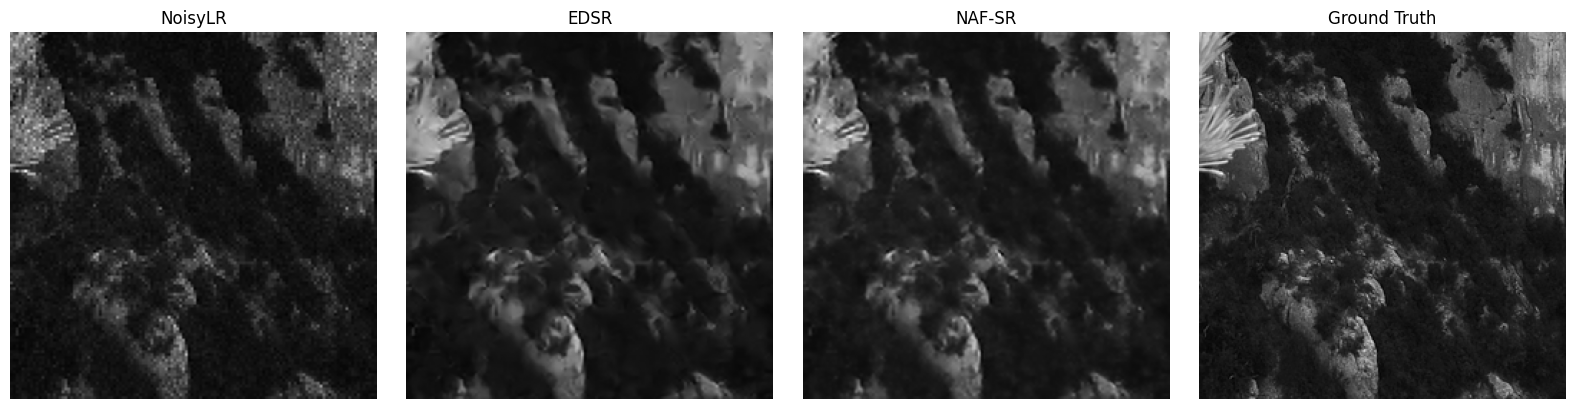

In [36]:
sample_file = test_files[0]

gt_img = np.load(
    os.path.join(
        GT_PATH,
        sample_file
    )
)

lr_img = np.load(
    os.path.join(
        NOISY_PATH,
        sample_file
    )
)

nafsr_img = np.load(
    os.path.join(
        RESTORED_DIR,
        sample_file
    )
)

edsr_img = np.load(
    os.path.join(
        "../results/edsr/restored",
        sample_file
    )
)

plt.figure(figsize=(16,4))

images = [
    lr_img,
    edsr_img,
    nafsr_img,
    gt_img
]

titles = [
    "NoisyLR",
    "EDSR",
    "NAF-SR",
    "Ground Truth"
]

for i in range(4):

    plt.subplot(1,4,i+1)

    plt.imshow(
        images[i],
        cmap="gray"
    )

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "../results/nafsr/comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
avg_psnr = np.mean(psnr_scores)
avg_ssim = np.mean(ssim_scores)
avg_mse = np.mean(mse_scores)
avg_time = np.mean(inference_times)

median_psnr = np.median(psnr_scores)
median_ssim = np.median(ssim_scores)

print("========== NAF-SR FINAL TEST RESULTS ==========")

print(f"Average PSNR : {avg_psnr:.6f} dB")
print(f"Median  PSNR : {median_psnr:.6f} dB")

print(f"Average SSIM : {avg_ssim:.6f}")
print(f"Median  SSIM : {median_ssim:.6f}")

print(f"Average MSE  : {avg_mse:.8f}")

print(f"Average inference time : {avg_time:.3f} ms/image")

print("\nImages tested:", len(psnr_scores))

========== NAF-SR FINAL TEST RESULTS ==========
Average PSNR : 27.840080 dB
Median  PSNR : 27.793488 dB
Average SSIM : 0.743259
Median  SSIM : 0.778634
Average MSE  : 0.00266457
Average inference time : 30.387 ms/image

Images tested: 320


In [38]:
baseline_df = pd.DataFrame({
    "Method": [
        "Bicubic",
        "SRCNN",
        "DnCNN",
        "EDSR",
        "NAF-SR"
    ],

    "PSNR_dB": [
        22.478415628140233,
        27.52943205674495,
        27.893001035080903,
        27.986647229958713,
        avg_psnr
    ],

    "SSIM": [
        0.5116624465067319,
        0.7250710888767316,
        0.7249596254696442,
        0.7425061760836545,
        avg_ssim
    ],

    "MSE": [
        0.007338321273890881,
        0.0027344456903774946,
        0.0025748269964531107,
        0.0026003361484997337,
        avg_mse
    ]
})

baseline_df

,Method,PSNR_dB,SSIM,MSE
0,Bicubic,22.478416,0.511662,0.007338
1,SRCNN,27.529432,0.725071,0.002734
2,DnCNN,27.893001,0.724960,0.002575
3,EDSR,27.986647,0.742506,0.002600
4,NAF-SR,27.840080,0.743259,0.002665


In [39]:
edsr_psnr = 27.986647229958713
edsr_ssim = 0.7425061760836545
edsr_mse = 0.0026003361484997337

print("========== NAF-SR vs EDSR ==========")

print(
    f"PSNR difference : "
    f"{avg_psnr - edsr_psnr:+.4f} dB"
)

print(
    f"SSIM difference : "
    f"{avg_ssim - edsr_ssim:+.4f}"
)

print(
    f"MSE difference  : "
    f"{avg_mse - edsr_mse:+.8f}"
)

========== NAF-SR vs EDSR ==========
PSNR difference : -0.1466 dB
SSIM difference : +0.0008
MSE difference  : +0.00006424


In [40]:
# ============================================
# NAF-SR FAILURE CASE ANALYSIS
# ============================================

analysis_df = metrics_df.copy()

print("========== PERFORMANCE DISTRIBUTION ==========")

print("\nPSNR")
print(analysis_df["PSNR_dB"].describe())

print("\nSSIM")
print(analysis_df["SSIM"].describe())

print("\nMSE")
print(analysis_df["MSE"].describe())


# -------------------------------
# Worst images by PSNR
# -------------------------------

worst_psnr = analysis_df.nsmallest(
    20,
    "PSNR_dB"
)

print("\n========== WORST 20 PSNR IMAGES ==========")
display(
    worst_psnr[
        ["Filename", "PSNR_dB", "SSIM", "MSE"]
    ]
)


# -------------------------------
# Worst images by SSIM
# -------------------------------

worst_ssim = analysis_df.nsmallest(
    20,
    "SSIM"
)

print("\n========== WORST 20 SSIM IMAGES ==========")
display(
    worst_ssim[
        ["Filename", "PSNR_dB", "SSIM", "MSE"]
    ]
)


# -------------------------------
# Count difficult cases
# -------------------------------

print("\n========== FAILURE COUNTS ==========")

print(
    "PSNR < 25 dB:",
    (analysis_df["PSNR_dB"] < 25).sum()
)

print(
    "PSNR < 27 dB:",
    (analysis_df["PSNR_dB"] < 27).sum()
)

print(
    "SSIM < 0.60:",
    (analysis_df["SSIM"] < 0.60).sum()
)

print(
    "SSIM < 0.70:",
    (analysis_df["SSIM"] < 0.70).sum()
)

print(
    "SSIM > 0.85:",
    (analysis_df["SSIM"] > 0.85).sum()
)

========== PERFORMANCE DISTRIBUTION ==========

PSNR
count    320.000000
mean      27.840080
std        4.131113
min       10.777232
25%       24.760297
50%       27.793488
75%       30.547077
max       38.105403
Name: PSNR_dB, dtype: float64

SSIM
count    320.000000
mean       0.743259
std        0.151852
min        0.212099
25%        0.688224
50%        0.778634
75%        0.853055
max        0.953341
Name: SSIM, dtype: float64

MSE
count    320.000000
mean       0.002665
std        0.005074
min        0.000155
25%        0.000882
50%        0.001662
75%        0.003342
max        0.083614
Name: MSE, dtype: float64

========== WORST 20 PSNR IMAGES ==========


,Filename,PSNR_dB,SSIM,MSE
28,000627.npy,10.777232,0.252718,0.083614
262,002041.npy,17.149817,0.424307,0.019276
234,002317.npy,18.991275,0.542376,0.012615
223,002264.npy,19.826545,0.817184,0.010407
46,002393.npy,20.032518,0.692392,0.009925
105,000641.npy,20.512432,0.212099,0.008887
297,001215.npy,20.764962,0.750735,0.008385
172,000206.npy,20.918162,0.689035,0.008094
189,000804.npy,20.948009,0.632894,0.008039
109,001636.npy,20.964261,0.792475,0.008009



========== WORST 20 SSIM IMAGES ==========


,Filename,PSNR_dB,SSIM,MSE
105,000641.npy,20.512432,0.212099,0.008887
211,002695.npy,22.863072,0.223219,0.005172
28,000627.npy,10.777232,0.252718,0.083614
258,001363.npy,23.854382,0.253895,0.004117
58,002385.npy,22.187491,0.265000,0.006043
222,000763.npy,23.358229,0.265309,0.004615
175,000870.npy,24.501338,0.279429,0.003547
85,000293.npy,25.897357,0.313907,0.002572
176,000397.npy,25.148566,0.319096,0.003056
137,002038.npy,25.473774,0.333267,0.002835



========== FAILURE COUNTS ==========
PSNR < 25 dB: 88
PSNR < 27 dB: 141
SSIM < 0.60: 47
SSIM < 0.70: 93
SSIM > 0.85: 83


In [41]:
# ============================================
# BEST / MEDIAN / WORST NAF-SR CASES
# ============================================

sorted_df = analysis_df.sort_values("PSNR_dB")

n = len(sorted_df)

worst_case = sorted_df.iloc[0]
q25_case = sorted_df.iloc[n // 4]
median_case = sorted_df.iloc[n // 2]
q75_case = sorted_df.iloc[(3 * n) // 4]
best_case = sorted_df.iloc[-1]

case_summary = pd.DataFrame([
    ["Worst",
     worst_case["Filename"],
     worst_case["PSNR_dB"],
     worst_case["SSIM"],
     worst_case["MSE"]],

    ["25th percentile",
     q25_case["Filename"],
     q25_case["PSNR_dB"],
     q25_case["SSIM"],
     q25_case["MSE"]],

    ["Median",
     median_case["Filename"],
     median_case["PSNR_dB"],
     median_case["SSIM"],
     median_case["MSE"]],

    ["75th percentile",
     q75_case["Filename"],
     q75_case["PSNR_dB"],
     q75_case["SSIM"],
     q75_case["MSE"]],

    ["Best",
     best_case["Filename"],
     best_case["PSNR_dB"],
     best_case["SSIM"],
     best_case["MSE"]]
],
columns=[
    "Case",
    "Filename",
    "PSNR_dB",
    "SSIM",
    "MSE"
])

display(case_summary)

,Case,Filename,PSNR_dB,SSIM,MSE
0,Worst,000627.npy,10.777232,0.252718,0.083614
1,25th percentile,002068.npy,24.763181,0.696490,0.003340
2,Median,001520.npy,27.858535,0.772284,0.001637
3,75th percentile,001863.npy,30.573698,0.621408,0.000876
4,Best,001095.npy,38.105403,0.953341,0.000155


In [43]:
# ============================================================
# OFFICIAL TEST SET — ROBUST INSPECTION
# ============================================================

import os
import zipfile
import numpy as np
import pandas as pd

TEST_ZIP = "../data/Test_NoisyLR.zip"
TEST_DIR = "../data/Test_NoisyLR"

if not os.path.exists(TEST_DIR):
    with zipfile.ZipFile(TEST_ZIP, "r") as z:
        z.extractall(TEST_DIR)

print("Extracted to:", TEST_DIR)

# Find .npy files recursively
test_files = []

for root, dirs, files in os.walk(TEST_DIR):
    for f in files:
        if f.endswith(".npy"):
            test_files.append(
                os.path.join(root, f)
            )

test_files = sorted(test_files)

print("Number of test images:", len(test_files))


def load_test_array(path):

    # First try normal numeric ndarray
    try:
        x = np.load(
            path,
            allow_pickle=False
        )

    except ValueError:

        # Some files may contain a pickled object
        obj = np.load(
            path,
            allow_pickle=True
        )

        print(
            "Pickled/object file detected:",
            os.path.basename(path),
            "| type:",
            type(obj),
            "| dtype:",
            getattr(obj, "dtype", None)
        )

        # Object ndarray containing one item
        if (
            isinstance(obj, np.ndarray)
            and
            obj.dtype == object
        ):

            if obj.shape == ():
                obj = obj.item()

            elif obj.size == 1:
                obj = obj.reshape(-1)[0]


        # Common dictionary cases
        if isinstance(obj, dict):

            print(
                "Dictionary keys:",
                obj.keys()
            )

            candidate_keys = [
                "image",
                "img",
                "data",
                "noisy",
                "NoisyLR",
                "lr",
                "input"
            ]

            found = False

            for key in candidate_keys:

                if key in obj:

                    x = obj[key]
                    found = True
                    break

            if not found:

                raise ValueError(
                    f"Could not determine image key in {path}. "
                    f"Available keys: {list(obj.keys())}"
                )

        else:
            x = obj


    x = np.asarray(
        x
    ).astype(
        np.float32
    )

    # Remove unnecessary singleton dimensions
    x = np.squeeze(x)

    if x.ndim != 2:

        raise ValueError(
            f"Unexpected array shape for "
            f"{os.path.basename(path)}: {x.shape}"
        )

    return x


records = []
bad_files = []

for path in test_files:

    try:

        x = load_test_array(
            path
        )

        records.append({
            "filename":
                os.path.basename(path),

            "shape":
                str(x.shape),

            "min":
                float(x.min()),

            "max":
                float(x.max()),

            "mean":
                float(x.mean()),

            "std":
                float(x.std()),

            "p01":
                float(
                    np.percentile(x, 1)
                ),

            "p99":
                float(
                    np.percentile(x, 99)
                )
        })

    except Exception as e:

        bad_files.append(
            (
                path,
                str(e)
            )
        )


test_stats = pd.DataFrame(
    records
)

print(
    "\nSuccessfully loaded:",
    len(test_stats)
)

print(
    "Failed:",
    len(bad_files)
)

if bad_files:

    print(
        "\nProblem files:"
    )

    for item in bad_files[:20]:
        print(item)


display(
    test_stats.head()
)


print(
    "\n========== TEST SET SUMMARY =========="
)

print(
    "\nShapes:"
)

print(
    test_stats[
        "shape"
    ].value_counts()
)


print(
    "\nIntensity statistics:"
)

display(
    test_stats[
        [
            "min",
            "max",
            "mean",
            "std",
            "p01",
            "p99"
        ]
    ].describe()
)

Extracted to: ../data/Test_NoisyLR
Number of test images: 800

Successfully loaded: 400
Failed: 400

Problem files:
('../data/Test_NoisyLR/__MACOSX/NoisyLR/._000000.npy', "Failed to interpret file '../data/Test_NoisyLR/__MACOSX/NoisyLR/._000000.npy' as a pickle")
('../data/Test_NoisyLR/__MACOSX/NoisyLR/._000001.npy', "Failed to interpret file '../data/Test_NoisyLR/__MACOSX/NoisyLR/._000001.npy' as a pickle")
('../data/Test_NoisyLR/__MACOSX/NoisyLR/._000002.npy', "Failed to interpret file '../data/Test_NoisyLR/__MACOSX/NoisyLR/._000002.npy' as a pickle")
('../data/Test_NoisyLR/__MACOSX/NoisyLR/._000003.npy', "Failed to interpret file '../data/Test_NoisyLR/__MACOSX/NoisyLR/._000003.npy' as a pickle")
('../data/Test_NoisyLR/__MACOSX/NoisyLR/._000004.npy', "Failed to interpret file '../data/Test_NoisyLR/__MACOSX/NoisyLR/._000004.npy' as a pickle")
('../data/Test_NoisyLR/__MACOSX/NoisyLR/._000005.npy', "Failed to interpret file '../data/Test_NoisyLR/__MACOSX/NoisyLR/._000005.npy' as a pickl

,filename,shape,min,max,mean,std,p01,p99
0,000000.npy,"(128, 128)",0.001030,1.540614,0.659532,0.293254,0.099513,1.237199
1,000001.npy,"(128, 128)",-0.015904,1.440885,0.430126,0.197662,0.071462,0.958034
2,000002.npy,"(128, 128)",0.001369,1.514864,0.726027,0.233610,0.057264,1.183296
3,000003.npy,"(128, 128)",-0.001299,1.255682,0.210611,0.102893,0.036262,0.440887
4,000004.npy,"(128, 128)",-0.037353,1.584476,0.448482,0.257206,0.065918,1.183864



========== TEST SET SUMMARY ==========

Shapes:
shape
(128, 128)    400
Name: count, dtype: int64

Intensity statistics:


,min,max,mean,std,p01,p99
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,-0.022180,1.433379,0.442742,0.220269,0.072445,0.995408
std,0.041924,0.187564,0.166062,0.069244,0.089956,0.199534
min,-0.224881,0.774162,0.033245,0.033836,-0.069310,0.121574
25%,-0.039760,1.314076,0.332813,0.171715,0.011643,0.894694
50%,-0.012262,1.444694,0.433126,0.215214,0.048246,1.022694
75%,0.002117,1.547853,0.549178,0.264444,0.099017,1.140341
max,0.126504,2.158016,0.904716,0.421744,0.515131,1.373726


In [44]:
# ============================================================
# CLEAN OFFICIAL TEST FILE LIST
# ============================================================

TEST_DIR = "../data/Test_NoisyLR"

test_files = []

for root, dirs, files in os.walk(TEST_DIR):

    # Ignore macOS metadata folders
    if "__MACOSX" in root:
        continue

    for f in files:

        # Ignore hidden metadata files
        if f.startswith("._"):
            continue

        if f.endswith(".npy"):
            test_files.append(
                os.path.join(root, f)
            )

test_files = sorted(test_files)

print("Valid official test images:", len(test_files))

print("First 5:")
for f in test_files[:5]:
    print(f)

Valid official test images: 400
First 5:
../data/Test_NoisyLR/NoisyLR/000000.npy
../data/Test_NoisyLR/NoisyLR/000001.npy
../data/Test_NoisyLR/NoisyLR/000002.npy
../data/Test_NoisyLR/NoisyLR/000003.npy
../data/Test_NoisyLR/NoisyLR/000004.npy


In [45]:
# ============================================================
# NAF-SR INFERENCE ON OFFICIAL TEST SET
# ============================================================

OFFICIAL_OUTPUT_DIR = "../results/nafsr/official_test_outputs"

os.makedirs(
    OFFICIAL_OUTPUT_DIR,
    exist_ok=True
)

official_records = []

best_model.eval()

total_start = time.perf_counter()

with torch.no_grad():

    for path in tqdm(
        test_files,
        desc="Official Test Inference"
    ):

        # -------------------------
        # Load input
        # -------------------------

        lr_np = np.load(
            path
        ).astype(
            np.float32
        )

        input_min = float(
            lr_np.min()
        )

        input_max = float(
            lr_np.max()
        )

        input_mean = float(
            lr_np.mean()
        )

        input_std = float(
            lr_np.std()
        )


        # -------------------------
        # Tensor
        # -------------------------

        lr_tensor = (
            torch.from_numpy(
                lr_np
            )
            .unsqueeze(0)
            .unsqueeze(0)
            .to(
                device,
                non_blocking=True
            )
        )


        if device.type == "cuda":
            torch.cuda.synchronize()

        start = time.perf_counter()


        output = best_model(
            lr_tensor
        )


        if device.type == "cuda":
            torch.cuda.synchronize()


        inference_ms = (
            time.perf_counter()
            -
            start
        ) * 1000


        # -------------------------
        # Final restored image
        # -------------------------

        output = torch.clamp(
            output,
            0,
            1
        )


        restored = (
            output
            .squeeze()
            .cpu()
            .numpy()
            .astype(
                np.float32
            )
        )


        # -------------------------
        # Save output
        # -------------------------

        filename = os.path.basename(
            path
        )


        np.save(
            os.path.join(
                OFFICIAL_OUTPUT_DIR,
                filename
            ),
            restored
        )


        official_records.append({

            "Filename":
                filename,

            "Input_Min":
                input_min,

            "Input_Max":
                input_max,

            "Input_Mean":
                input_mean,

            "Input_STD":
                input_std,

            "Output_Min":
                float(
                    restored.min()
                ),

            "Output_Max":
                float(
                    restored.max()
                ),

            "Output_Mean":
                float(
                    restored.mean()
                ),

            "Output_STD":
                float(
                    restored.std()
                ),

            "Inference_ms":
                inference_ms
        })


total_time = (
    time.perf_counter()
    -
    total_start
)


official_df = pd.DataFrame(
    official_records
)


print(
    "\n========== OFFICIAL TEST INFERENCE =========="
)

print(
    "Images:",
    len(official_df)
)

print(
    f"Total notebook inference time: "
    f"{total_time:.3f} s"
)

print(
    f"Average network time: "
    f"{official_df['Inference_ms'].mean():.3f} ms/image"
)

print(
    "Output folder:",
    OFFICIAL_OUTPUT_DIR
)

Official Test Inference: 100%|██████████| 400/400 [00:04<00:00, 95.59it/s]


========== OFFICIAL TEST INFERENCE ==========
Images: 400
Total notebook inference time: 4.189 s
Average network time: 9.112 ms/image
Output folder: ../results/nafsr/official_test_outputs


In [46]:
print(
    "========== INPUT vs OUTPUT STATISTICS =========="
)

display(
    official_df[
        [
            "Input_Mean",
            "Input_STD",
            "Output_Mean",
            "Output_STD",
            "Inference_ms"
        ]
    ].describe()
)

========== INPUT vs OUTPUT STATISTICS ==========


,Input_Mean,Input_STD,Output_Mean,Output_STD,Inference_ms
count,400.000000,400.000000,400.000000,400.000000,400.000000
mean,0.442742,0.220269,0.442789,0.194670,9.111999
std,0.166062,0.069244,0.166558,0.072086,0.565791
min,0.033245,0.033836,0.033480,0.027465,8.884342
25%,0.332813,0.171715,0.332336,0.146229,8.912327
50%,0.433126,0.215214,0.433108,0.193275,8.925071
75%,0.549178,0.264444,0.548932,0.243288,8.966833
max,0.904716,0.421744,0.903471,0.394377,13.255918


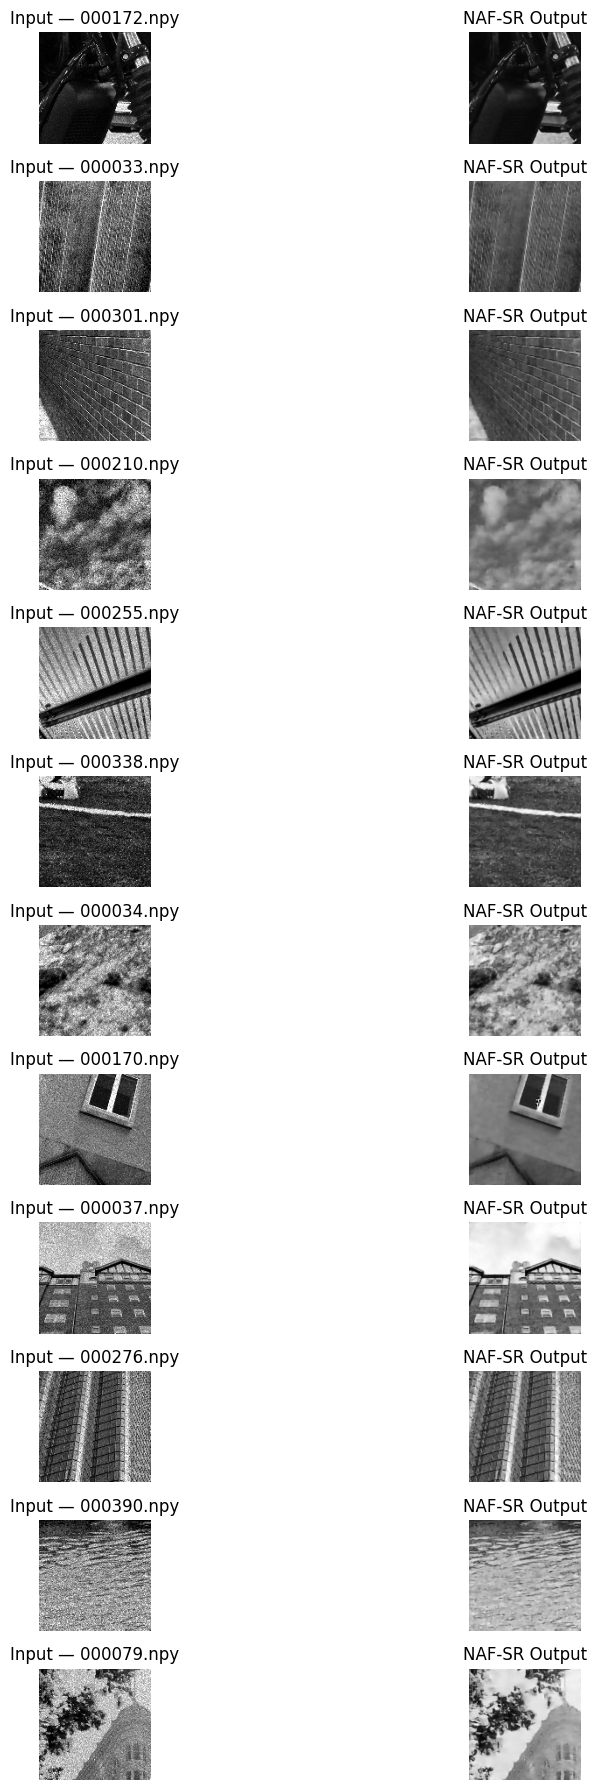

In [47]:
# ============================================================
# VISUAL CHECK — OFFICIAL TEST OUTPUTS
# ============================================================

rng = np.random.default_rng(42)

indices = rng.choice(
    len(test_files),
    size=12,
    replace=False
)

plt.figure(
    figsize=(12,18)
)

for row, idx in enumerate(indices):

    path = test_files[idx]

    filename = os.path.basename(
        path
    )

    lr_img = np.load(
        path
    ).astype(
        np.float32
    )

    restored = np.load(
        os.path.join(
            OFFICIAL_OUTPUT_DIR,
            filename
        )
    )


    # Input
    plt.subplot(
        12,
        2,
        row*2 + 1
    )

    lo = np.percentile(
        lr_img,
        1
    )

    hi = np.percentile(
        lr_img,
        99
    )

    plt.imshow(
        lr_img,
        cmap="gray",
        vmin=lo,
        vmax=hi
    )

    plt.title(
        f"Input — {filename}"
    )

    plt.axis("off")


    # Output
    plt.subplot(
        12,
        2,
        row*2 + 2
    )

    plt.imshow(
        restored,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        "NAF-SR Output"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()